# Coffee Plant Disease Classification
**Dataset:** JMuBEN Coffee Dataset

**Source:** https://www.kaggle.com/datasets/noamaanabdulazeem/jmuben-coffee-dataset

**Models:** Custom CNN · MobileNetV2 · EfficientNetB0

**Framework:** TensorFlow / Keras


## Section 1 — Imports & Configuration
Installs required packages, imports all libraries, fixes random seeds for reproducibility, and defines global hyperparameters used throughout the notebook.

In [1]:
!pip install kagglehub tensorflow scikit-learn matplotlib seaborn pandas pillow -q

In [2]:
import os, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["MKL_NUM_THREADS"]        = "1"
os.environ["OMP_NUM_THREADS"]        = "1"

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, Dropout, Input, Conv2D, BatchNormalization,
    Activation, Add, SeparableConv2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

from collections import Counter
from PIL import Image
import kagglehub
import hashlib

%matplotlib inline
print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")


TensorFlow : 2.21.0
NumPy      : 2.2.5


In [3]:
# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# ── Global hyperparameters ────────────────────────────────────────────────────
# 96×96 is sufficient for MobileNetV2 (min 32×32) and EfficientNetB0 (min 32×32).
# Smaller resolution cuts memory and compute significantly vs 224×224.
IMG_SIZE      = (96, 96)
BATCH_SIZE    = 32 
EPOCHS        = 20
LR            = 1e-3
FINE_TUNE_LR  = 1e-5

print("Configuration:")
print(f"  IMG_SIZE   : {IMG_SIZE}")
print(f"  BATCH_SIZE : {BATCH_SIZE}")
print(f"  EPOCHS     : {EPOCHS}")
print(f"  LR         : {LR}")


Configuration:
  IMG_SIZE   : (96, 96)
  BATCH_SIZE : 32
  EPOCHS     : 20
  LR         : 0.001


## Section 2 — Dataset Download, Setup & Deduplication
Downloads the JMuBEN Coffee Dataset from Kaggle via `kagglehub`, inspects the directory structure, identifies all image files with their disease class labels, and removes exact duplicate images via MD5 hashing so that all downstream EDA and modelling work on clean, unique images only.

In [4]:
# ── 2.1 Download latest version ───────────────────
path = kagglehub.dataset_download("noamaanabdulazeem/jmuben-coffee-dataset")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\enock\.cache\kagglehub\datasets\noamaanabdulazeem\jmuben-coffee-dataset\versions\2


In [5]:
# ── 2.2 Locate the root directory containing class sub-folders ───────────────────
DATA_DIR = None
for root, dirs, files in os.walk(path):
    img_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if img_files and len(dirs) == 0:          # leaf node with images
        DATA_DIR = os.path.dirname(root)
        break

# Fallback: use path directly if classes are immediate sub-directories
if DATA_DIR is None:
    for candidate in [path] + [os.path.join(path, d) for d in os.listdir(path)]:
        if os.path.isdir(candidate):
            sub = [d for d in os.listdir(candidate) if os.path.isdir(os.path.join(candidate, d))]
            if sub:
                DATA_DIR = candidate
                break

print(f"DATA_DIR resolved to: {DATA_DIR}")
print("\nTop-level contents:")
for item in sorted(os.listdir(DATA_DIR)):
    item_path = os.path.join(DATA_DIR, item)
    if os.path.isdir(item_path):
        n = len([f for f in os.listdir(item_path) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f"{item:<40} ({n} images)")

DATA_DIR resolved to: C:\Users\enock\.cache\kagglehub\datasets\noamaanabdulazeem\jmuben-coffee-dataset\versions\2\JMuBEN

Top-level contents:
Cercospora                               (7681 images)
Healthy                                  (18983 images)
Leaf rust                                (8336 images)
Miner                                    (16978 images)
Phoma                                    (6571 images)


In [6]:
# ── 2.3 Collect all file paths and labels ────────────────────────────────────────
all_files, all_labels = [], []

for class_name in sorted(os.listdir(DATA_DIR)):
    class_path = os.path.join(DATA_DIR, class_name)
    if not os.path.isdir(class_path):
        continue
    for fname in os.listdir(class_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_files.append(os.path.join(class_path, fname))
            all_labels.append(class_name)

CLASS_NAMES = sorted(set(all_labels))
NUM_CLASSES = len(CLASS_NAMES)

print(f"Total images   : {len(all_files)}")
print(f"Unique classes : {NUM_CLASSES}")
print(f"Classes        : {CLASS_NAMES}")

Total images   : 58549
Unique classes : 5
Classes        : ['Cercospora', 'Healthy', 'Leaf rust', 'Miner', 'Phoma']


In [7]:
# ── 2.4 Deduplication — Remove exact duplicate images ────────────────────────────────────────
def image_hash(filepath):
    """MD5 hash of raw image bytes — fast duplicate detector."""
    with open(filepath, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

# Build hash → first-seen filepath mapping
print("Deduplicating images...")
seen_hashes = {}
unique_files, unique_labels = [], []

for fp, lbl in zip(all_files, all_labels):
    h = image_hash(fp)
    if h not in seen_hashes:
        seen_hashes[h] = fp
        unique_files.append(fp)
        unique_labels.append(lbl)

print(f"Original : {len(all_files)} images")
print(f"Unique   : {len(unique_files)} images")
print(f"Removed  : {len(all_files) - len(unique_files)} duplicates")

# Then we use unique_files / unique_labels for your split
all_files  = unique_files
all_labels = unique_labels

print("\nPer-class counts after deduplication:")
for cls, cnt in sorted(Counter(all_labels).items()):
    print(f"  {cls:<35} : {cnt}")

Deduplicating images...
Original : 58549 images
Unique   : 3756 images
Removed  : 54793 duplicates

Per-class counts after deduplication:
  Cercospora                          : 322
  Healthy                             : 62
  Leaf rust                           : 1042
  Miner                               : 1639
  Phoma                               : 691


## Section 3 — Exploratory Data Analysis (EDA)
Visualises class distribution, dataset split proportions, sample images per class, pixel intensity statistics, and a data augmentation preview — all computed on the **deduplicated** dataset, providing an accurate view of class imbalance and visual diversity before modelling.

In [8]:
# ── 3.1 Class counts ─────────────────────────────────────────────────────────
counts = Counter(all_labels)
count_df = pd.DataFrame({
    'Disease Class': list(counts.keys()),
    'Count'        : list(counts.values())
}).sort_values('Count', ascending=False).reset_index(drop=True)

count_df['% of Total'] = (count_df['Count'] / count_df['Count'].sum() * 100).round(2)
imbalance_ratio = count_df['Count'].max() / count_df['Count'].min()

print(f"{'='*55}")
print(f"  Classes              : {NUM_CLASSES}")
print(f"  Total images         : {len(all_files)}")
print(f"  Imbalance ratio      : {imbalance_ratio:.1f}x")
print(f"  Mean images/class    : {count_df['Count'].mean():.0f}")
print(f"{'='*55}")
print(count_df.to_string(index=False))

  Classes              : 5
  Total images         : 3756
  Imbalance ratio      : 26.4x
  Mean images/class    : 751
Disease Class  Count  % of Total
        Miner   1639       43.64
    Leaf rust   1042       27.74
        Phoma    691       18.40
   Cercospora    322        8.57
      Healthy     62        1.65


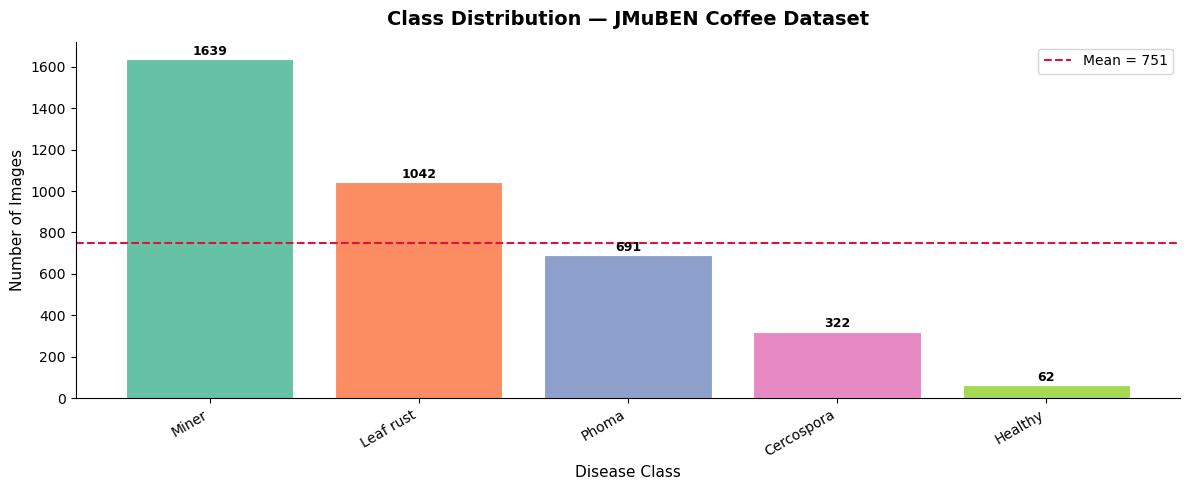

In [9]:
# ── 3.2 Class Distribution Bar Chart ─────────────────────────────────────────
palette = sns.color_palette('Set2', NUM_CLASSES)
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(count_df['Disease Class'], count_df['Count'],
              color=palette, edgecolor='white', linewidth=0.8)

for bar, cnt in zip(bars, count_df['Count']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(cnt), ha='center', va='bottom', fontsize=9, fontweight='bold')

mean_val = count_df['Count'].mean()
ax.axhline(mean_val, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Mean = {mean_val:.0f}')

ax.set_title('Class Distribution — JMuBEN Coffee Dataset', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Disease Class', fontsize=11)
ax.set_ylabel('Number of Images', fontsize=11)
ax.set_xticklabels(count_df['Disease Class'], rotation=30, ha='right')
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150)
plt.show()

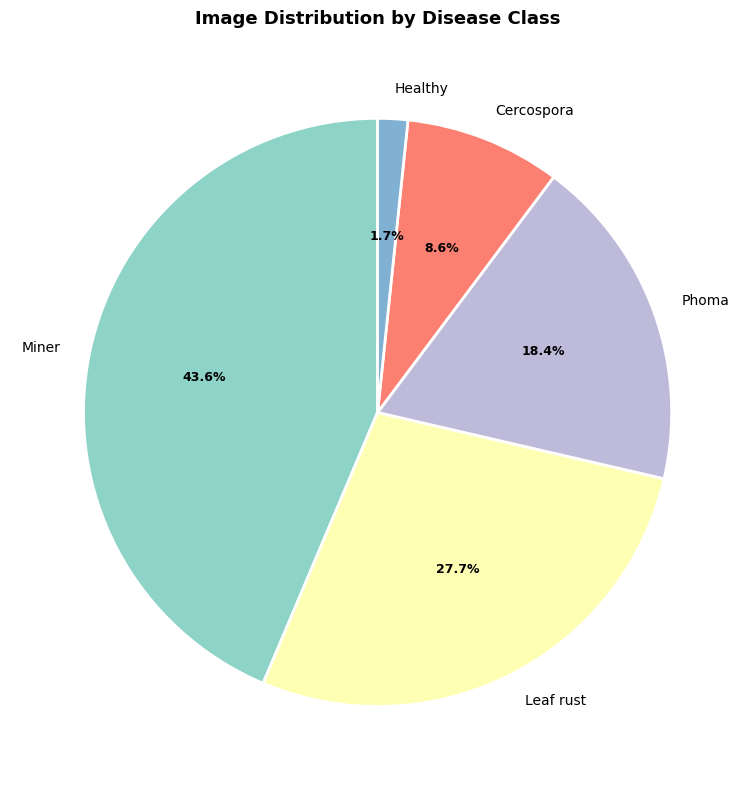

In [10]:
# ── 3.3 Pie Chart — Proportion per Class ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))
wedge_props = {'edgecolor': 'white', 'linewidth': 2}
wedges, texts, autotexts = ax.pie(
    count_df['Count'],
    labels=count_df['Disease Class'],
    autopct='%1.1f%%',
    colors=sns.color_palette('Set3', NUM_CLASSES),
    startangle=90,
    wedgeprops=wedge_props
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')

ax.set_title('Image Distribution by Disease Class', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_class_pie.png', dpi=150)
plt.show()

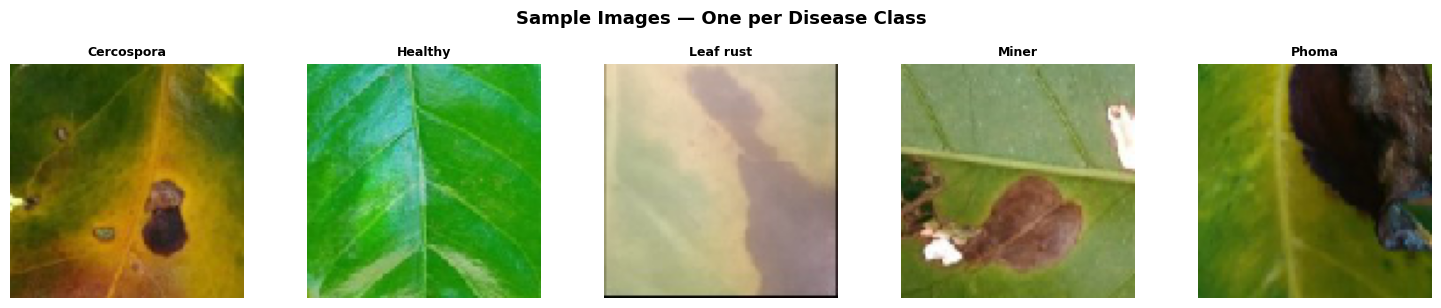

In [11]:
# ── 3.4 Sample Images — One per Class ────────────────────────────────────────
ncols = min(NUM_CLASSES, 5)
nrows = (NUM_CLASSES + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
axes = axes.flatten() if NUM_CLASSES > 1 else [axes]

for idx, cls in enumerate(CLASS_NAMES):
    cls_files = [f for f, l in zip(all_files, all_labels) if l == cls]
    sample = random.choice(cls_files)
    img = load_img(sample, target_size=IMG_SIZE)
    axes[idx].imshow(img)
    axes[idx].set_title(cls.replace('_', ' '), fontsize=9, fontweight='bold')
    axes[idx].axis('off')

for j in range(NUM_CLASSES, len(axes)):
    axes[j].axis('off')

fig.suptitle('Sample Images — One per Disease Class', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

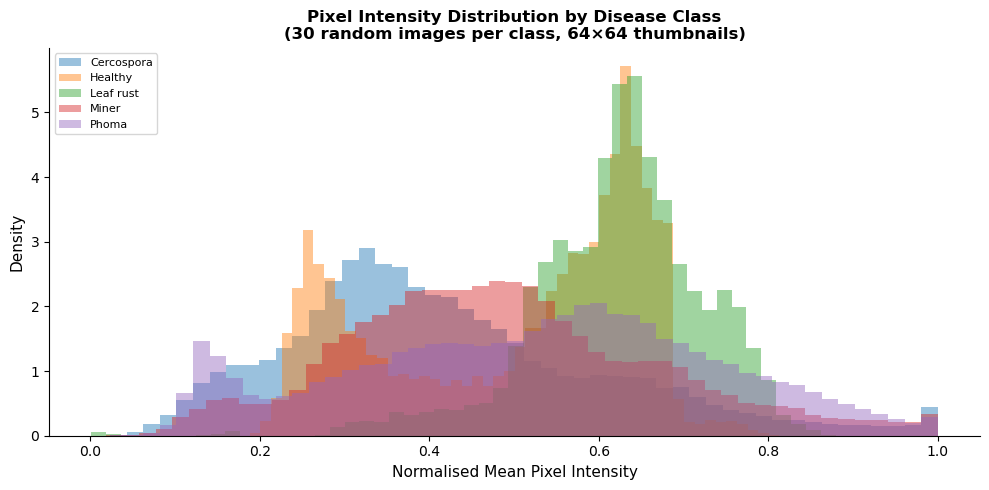

In [12]:
# ── 3.5 Pixel Intensity Distribution per Class ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
palette_cls = sns.color_palette('tab10', NUM_CLASSES)

for cls_idx, cls in enumerate(CLASS_NAMES):
    cls_files = [f for f, l in zip(all_files, all_labels) if l == cls]
    sample_paths = random.sample(cls_files, min(30, len(cls_files)))
    pixels = []
    for fp in sample_paths:
        img_arr = np.array(load_img(fp, target_size=(64, 64))) / 255.0
        pixels.extend(img_arr.mean(axis=2).flatten().tolist())
    ax.hist(pixels, bins=50, alpha=0.45, label=cls.replace('_', ' '),
            color=palette_cls[cls_idx], density=True)

ax.set_xlabel('Normalised Mean Pixel Intensity', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Pixel Intensity Distribution by Disease Class\n(30 random images per class, 64×64 thumbnails)', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=8)
sns.despine()
plt.tight_layout()
plt.savefig('eda_pixel_intensity.png', dpi=150)
plt.show()

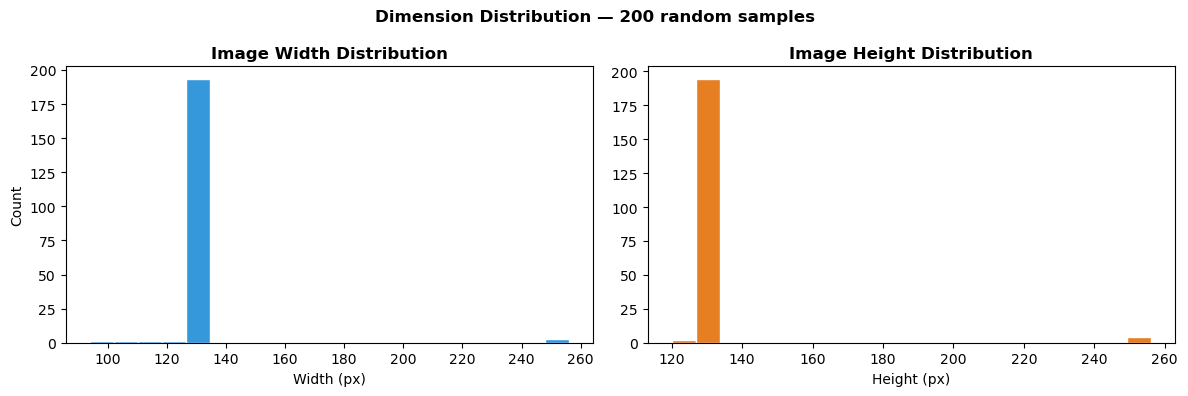

Width  — mean: 130px  |  min: 94px  |  max: 256px
Height — mean: 131px  |  min: 120px  |  max: 256px


In [13]:
# ── 3.6 Image Dimension Check ────────────────────────────────────────────────
sample_n = min(200, len(all_files))
sample_paths = random.sample(all_files, sample_n)
widths, heights = [], []

for fp in sample_paths:
    with Image.open(fp) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=20, color='#3498db', edgecolor='white')
axes[0].set_title('Image Width Distribution', fontweight='bold')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Count')

axes[1].hist(heights, bins=20, color='#e67e22', edgecolor='white')
axes[1].set_title('Image Height Distribution', fontweight='bold')
axes[1].set_xlabel('Height (px)')

fig.suptitle(f'Dimension Distribution — {sample_n} random samples', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_dimensions.png', dpi=150)
plt.show()

print(f"Width  — mean: {np.mean(widths):.0f}px  |  min: {min(widths)}px  |  max: {max(widths)}px")
print(f"Height — mean: {np.mean(heights):.0f}px  |  min: {min(heights)}px  |  max: {max(heights)}px")

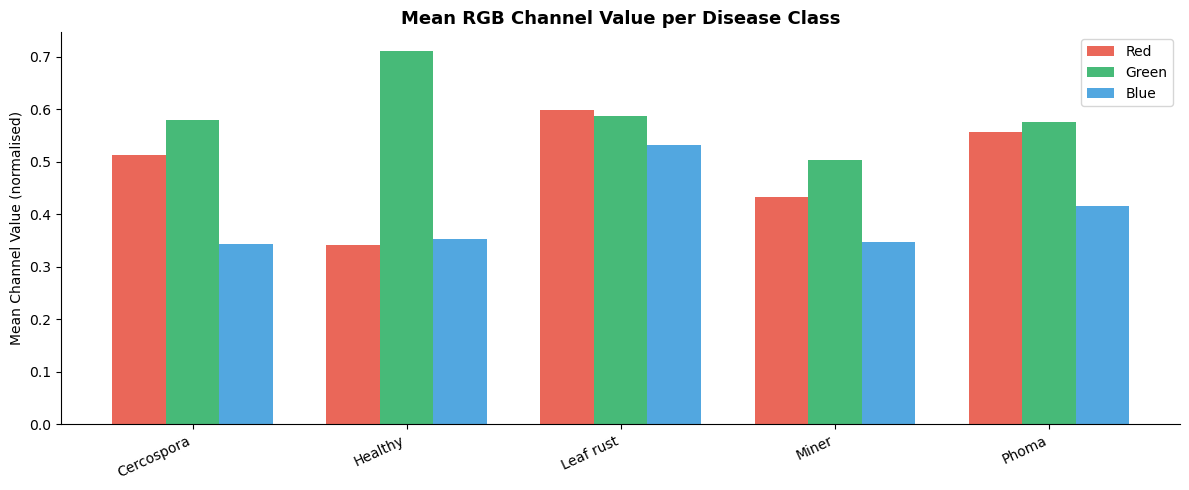

In [14]:
# ── 3.7 RGB Channel Mean per Class ───────────────────────────────────────────
channel_stats = []
for cls in CLASS_NAMES:
    cls_files = [f for f, l in zip(all_files, all_labels) if l == cls]
    imgs = [np.array(load_img(fp, target_size=(64, 64))) / 255.0
            for fp in random.sample(cls_files, min(20, len(cls_files)))]
    stack = np.stack(imgs)
    channel_stats.append({
        'Class': cls.replace('_', ' '),
        'R_mean': stack[:, :, :, 0].mean(),
        'G_mean': stack[:, :, :, 1].mean(),
        'B_mean': stack[:, :, :, 2].mean(),
    })

ch_df = pd.DataFrame(channel_stats)
x = np.arange(len(ch_df))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, ch_df['R_mean'], width, label='Red',   color='#e74c3c', alpha=0.85)
ax.bar(x, ch_df['G_mean'], width, label='Green', color='#27ae60', alpha=0.85)
ax.bar(x + width, ch_df['B_mean'], width, label='Blue',  color='#3498db', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(ch_df['Class'], rotation=25, ha='right')
ax.set_ylabel('Mean Channel Value (normalised)')
ax.set_title('Mean RGB Channel Value per Disease Class', fontsize=13, fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('eda_rgb_channels.png', dpi=150)
plt.show()

## Section 4 — Data Preparation
Performs a stratified 70 / 15 / 15 train–validation–test split on the deduplicated dataset, builds architecture-specific `ImageDataGenerator` pipelines with augmentation for training, and computes class weights to address imbalance.

In [15]:
# ── 4.1 Stratified 70 / 15 / 15 split ────────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    all_files, all_labels, test_size=0.30, stratify=all_labels, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

train_df = pd.DataFrame({'filename': X_train, 'class': y_train})
val_df   = pd.DataFrame({'filename': X_val,   'class': y_val})
test_df  = pd.DataFrame({'filename': X_test,  'class': y_test})

print(f"Train      : {len(X_train):>5}  ({len(X_train)/len(all_files)*100:.1f}%)")
print(f"Validation : {len(X_val):>5}  ({len(X_val)/len(all_files)*100:.1f}%)")
print(f"Test       : {len(X_test):>5}  ({len(X_test)/len(all_files)*100:.1f}%)")

Train      :  2629  (70.0%)
Validation :   563  (15.0%)
Test       :   564  (15.0%)


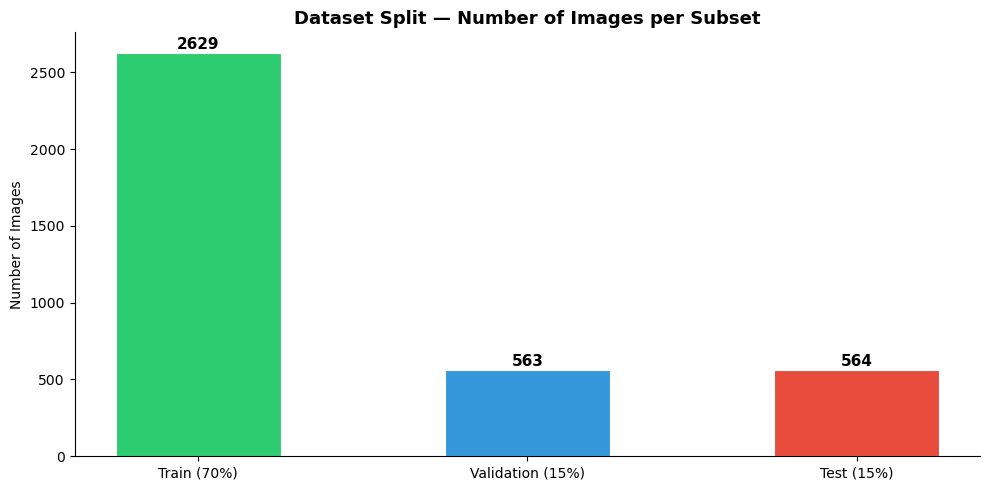

In [16]:
# ── 4.2 Split Visualisation ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
splits = ['Train (70%)', 'Validation (15%)', 'Test (15%)']
sizes  = [len(X_train), len(X_val), len(X_test)]
colors = ['#2ecc71', '#3498db', '#e74c3c']
bars   = ax.bar(splits, sizes, color=colors, edgecolor='white', linewidth=0.8, width=0.5)

for bar, sz in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(sz), ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Dataset Split — Number of Images per Subset', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Images')
sns.despine()
plt.tight_layout()
plt.savefig('data_split.png', dpi=150)
plt.show()

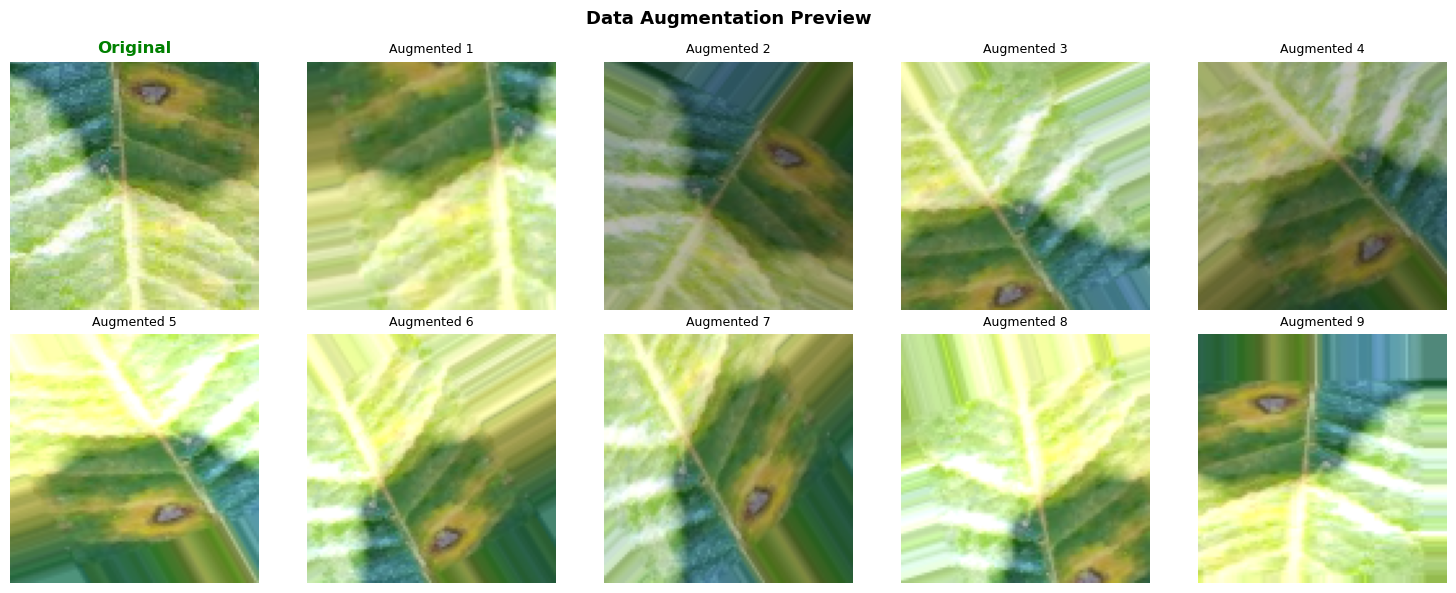

In [17]:
# ── 4.3 Augmentation Preview ──────────────────────────────────────────────────
aug_gen = ImageDataGenerator(
    rescale=1./255, rotation_range=40,
    width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.25, zoom_range=0.25,
    horizontal_flip=True, vertical_flip=True,
    brightness_range=[0.7, 1.3]
)

sample_img_path = all_files[0]
sample_img = img_to_array(load_img(sample_img_path, target_size=IMG_SIZE))
sample_img = sample_img.reshape((1,) + sample_img.shape)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
axes[0].imshow(load_img(sample_img_path, target_size=IMG_SIZE))
axes[0].set_title('Original', fontweight='bold', color='green')
axes[0].axis('off')

for i, batch in enumerate(aug_gen.flow(sample_img, batch_size=1, seed=SEED)):
    if i >= 9:
        break
    axes[i + 1].imshow(batch[0])
    axes[i + 1].set_title(f'Augmented {i+1}', fontsize=9)
    axes[i + 1].axis('off')

fig.suptitle('Data Augmentation Preview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_preview.png', dpi=150)
plt.show()

In [18]:
# ── 4.4 Generator Factory — Architecture-specific preprocessing ───────────────
#
#  Model                  | Expected Input Range | Preprocessing Function
#  Custom CNN             | [0, 1]               | rescale=1./255
#  MobileNetV2            | [-1, 1]              | mobilenet_v2.preprocess_input
#  EfficientNetB0         | [0, 255] (raw)       | efficientnet.preprocess_input

AUG_PARAMS = dict(
    rotation_range=35,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.25,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.75, 1.25]
)

def make_generators(preprocess_fn=None, rescale=None):
    assert not (preprocess_fn and rescale), \
        "Pass either preprocess_fn OR rescale, not both."
    train_datagen = ImageDataGenerator(
        rescale=rescale,
        preprocessing_function=preprocess_fn,
        **AUG_PARAMS
    )
    eval_datagen = ImageDataGenerator(
        rescale=rescale,
        preprocessing_function=preprocess_fn
    )
    flow_kw = dict(
        x_col='filename', y_col='class',
        target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical'
    )
    tr = train_datagen.flow_from_dataframe(train_df, shuffle=True,  **flow_kw)
    va = eval_datagen.flow_from_dataframe(val_df,   shuffle=False, **flow_kw)
    te = eval_datagen.flow_from_dataframe(test_df,  shuffle=False, **flow_kw)
    return tr, va, te

# Custom CNN generators: [0, 1]
train_gen_cnn, val_gen_cnn, test_gen_cnn = make_generators(rescale=1./255)

# MobileNetV2 generators: mobilenet_v2.preprocess_input -> [-1, 1]
train_gen_mob, val_gen_mob, test_gen_mob = make_generators(preprocess_fn=mobilenet_preprocess)

# EfficientNetB0 generators: efficientnet.preprocess_input -> [0, 255] normalised internally
train_gen_eff, val_gen_eff, test_gen_eff = make_generators(preprocess_fn=efficientnet_preprocess)

class_indices = train_gen_cnn.class_indices
NUM_CLASSES   = len(class_indices)
CLASS_NAMES   = list(class_indices.keys())

print(f"NUM_CLASSES : {NUM_CLASSES}")
print(f"CLASS_NAMES : {CLASS_NAMES}")


Found 2629 validated image filenames belonging to 5 classes.
Found 563 validated image filenames belonging to 5 classes.
Found 564 validated image filenames belonging to 5 classes.
Found 2629 validated image filenames belonging to 5 classes.
Found 563 validated image filenames belonging to 5 classes.
Found 564 validated image filenames belonging to 5 classes.
Found 2629 validated image filenames belonging to 5 classes.
Found 563 validated image filenames belonging to 5 classes.
Found 564 validated image filenames belonging to 5 classes.
NUM_CLASSES : 5
CLASS_NAMES : ['Cercospora', 'Healthy', 'Leaf rust', 'Miner', 'Phoma']


In [19]:
# ── 4.5 Class Weights (balanced strategy) ────────────────────────────────────
unique_cls   = np.array(sorted(class_indices.keys()))
weight_arr   = compute_class_weight('balanced', classes=unique_cls, y=y_train)
class_weight = {class_indices[cls]: w for cls, w in zip(unique_cls, weight_arr)}

idx_to_cls = {v: k for k, v in class_indices.items()}
print("Class weights:")
for idx, w in sorted(class_weight.items(), key=lambda x: x[1], reverse=True):
    print(f"  [{idx}] {idx_to_cls[idx]:<35} → {w:.4f}")

Class weights:
  [1] Healthy                             → 11.9500
  [0] Cercospora                          → 2.3369
  [4] Phoma                               → 1.0864
  [2] Leaf rust                           → 0.7213
  [3] Miner                               → 0.4584


## Section 5 — Model Architectures
Defines three deep learning architectures:
- **Model A** — Custom CNN: a compact from-scratch network using depthwise-separable convolutions and skip connections. ~0.5M parameters.
- **Model B** — MobileNetV2 (frozen → fine-tuned): transfer learning from ImageNet. Only 3.4M total parameters, designed for mobile/edge deployment. Phase 1 trains the head only; Phase 2 fine-tunes the top 20 backbone layers.
- **Model C** — EfficientNetB0 (frozen → fine-tuned): the smallest member of the EfficientNet family (~5.3M params), achieving strong accuracy with compound scaling. Phase 1 trains the head only; Phase 2 fine-tunes the top 20 backbone layers.


In [20]:
# ── 5A: Custom CNN ───────────────────────────────────────────────
# Uses depthwise-separable convolutions (SeparableConv2D) which factorize a
# standard convolution into a depthwise spatial filter + a pointwise 1x1
# convolution, reducing computation ~8-9x vs standard Conv2D at similar accuracy.
# Skip connections improve gradient flow without adding heavy parameter counts.

def sep_residual_block(x, filters, stride=1, l2_reg=1e-4):
    """residual block using SeparableConv2D."""
    shortcut = x
    x = SeparableConv2D(filters, 3, strides=stride, padding='same',
                        depthwise_regularizer=l2(l2_reg), use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SeparableConv2D(filters, 3, padding='same',
                        depthwise_regularizer=l2(l2_reg), use_bias=False)(x)
    x = BatchNormalization()(x)
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, strides=stride, padding='same',
                          kernel_regularizer=l2(l2_reg), use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)
    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x


def build_cnn(input_shape=(96, 96, 3), num_classes=NUM_CLASSES):
    inputs = Input(shape=input_shape)
    # Stem
    x = Conv2D(32, 3, strides=2, padding='same', use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    # Separable residual stages
    x = sep_residual_block(x, 64,  stride=1)   # 48x48
    x = sep_residual_block(x, 128, stride=2)   # 24x24
    x = sep_residual_block(x, 256, stride=2)   # 12x12
    # Head
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs, name='Custom_CNN')


custom_cnn = build_cnn()
custom_cnn.compile(
    optimizer=Adam(LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
custom_cnn.summary()


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 96, 96, 3)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 48, 48, 32)        │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 48, 48, 32)        │             128 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 48, 48, 32)        │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ separable_conv2d              │ (None, 48, 48, 64)        │           2,336 │ activation[0][0]           │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 48, 48, 64)        │             256 │ separable_conv2d[0][0]     │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 48, 48, 64)        │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ separable_conv2d_1            │ (None, 48, 48, 64)        │           4,672 │ activation_1[0][0]         │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 48, 48, 64)        │           2,048 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 48, 48, 64)        │             256 │ separable_conv2d_1[0][0]   │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 48, 48, 64)        │             256 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 48, 48, 64)        │               0 │ batch_normalization_2[0][… │
│                               │                           │                 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_2 (Activation)     │ (None, 48, 48, 64)        │               0 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ separable_conv2d_2            │ (None, 24, 24, 128)       │           8,76

 Total params: 217,989 (851.52 KB)

 Trainable params: 215,237 (840.77 KB)

 Non-trainable params: 2,752 (10.75 KB)

In [21]:
# ── 5B: MobileNetV2 — Transfer Learning (Frozen Backbone) ───────────────────
# MobileNetV2 introduces inverted residuals with linear bottlenecks and
# depthwise-separable convolutions. Total: ~3.4M parameters — ~7x fewer than
# ResNet50V2 (~25.6M) — making it ideal for fast training and deployment.
# Pre-trained on ImageNet; backbone frozen for Phase 1 (head-only training).

base_mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)
base_mobilenet.trainable = False

inputs_mob = Input(shape=(96, 96, 3))
x_mob      = base_mobilenet(inputs_mob, training=False)
x_mob      = GlobalAveragePooling2D()(x_mob)
x_mob      = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x_mob)
x_mob      = Dropout(0.4)(x_mob)
x_mob      = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x_mob)
x_mob      = Dropout(0.3)(x_mob)
out_mob    = Dense(NUM_CLASSES, activation='softmax')(x_mob)

mobilenet_model = Model(inputs_mob, out_mob, name='MobileNetV2_Frozen')
mobilenet_model.compile(
    optimizer=Adam(LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
mobilenet_model.summary()


Model: "MobileNetV2_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_96 (Functional)     │ (None, 3, 3, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,619,461 (9.99 MB)

 Trainable params: 361,477 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
# ── 5C: EfficientNetB0 — Transfer Learning (Frozen Backbone) ────────────────
# EfficientNetB0 uses compound scaling — uniformly scaling depth, width, and
# resolution — achieving better accuracy-efficiency trade-offs than prior models.
# Total: ~5.3M parameters. Pre-trained on ImageNet; backbone frozen for Phase 1.
# EfficientNet's built-in preprocessing expects raw [0,255] uint8-like
# floats and handles normalisation internally via its preprocess_input function.

base_efficientnet = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)
base_efficientnet.trainable = False

inputs_eff = Input(shape=(96, 96, 3))
x_eff      = base_efficientnet(inputs_eff, training=False)
x_eff      = GlobalAveragePooling2D()(x_eff)
x_eff      = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x_eff)
x_eff      = Dropout(0.4)(x_eff)
x_eff      = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x_eff)
x_eff      = Dropout(0.3)(x_eff)
out_eff    = Dense(NUM_CLASSES, activation='softmax')(x_eff)

efficientnet_model = Model(inputs_eff, out_eff, name='EfficientNetB0_Frozen')
efficientnet_model.compile(
    optimizer=Adam(LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
efficientnet_model.summary()


Model: "EfficientNetB0_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 3, 3, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,411,048 (16.83 MB)

 Trainable params: 361,477 (1.38 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [23]:
# ── 5D: Parameter Count Comparison ──────────────────────────────────────────
models_list = [
    ('Custom CNN', custom_cnn),
    ('MobileNetV2 (Frozen)', mobilenet_model),
    ('EfficientNetB0 (Frozen)', efficientnet_model),
]

print(f"{'Model':<30} {'Total Params':>15} {'Trainable':>15} {'Non-Trainable':>15} {'Size (MB)':>10}")
print('-' * 90)
for name, model in models_list:
    total     = model.count_params()
    trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
    non_train = total - trainable
    size_mb   = total * 4 / 1e6
    print(f"{name:<30} {total:>15,} {trainable:>15,} {non_train:>15,} {size_mb:>9.2f}")


Model                             Total Params       Trainable   Non-Trainable  Size (MB)
------------------------------------------------------------------------------------------
Custom CNN                             217,989         215,237           2,752      0.87
MobileNetV2 (Frozen)                 2,619,461         361,477       2,257,984     10.48
EfficientNetB0 (Frozen)              4,411,048         361,477       4,049,571     17.64


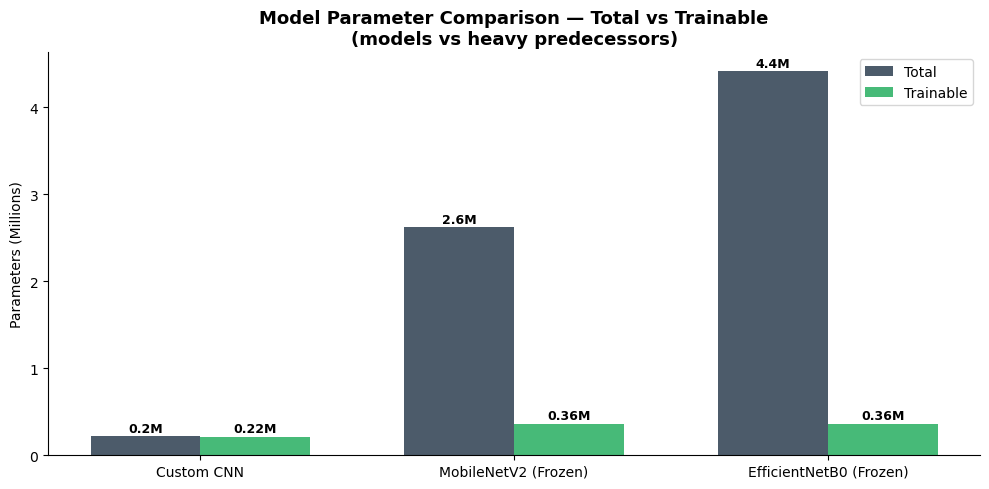

In [24]:
# ── 5E: Parameter Count Bar Chart ────────────────────────────────────────────
names_p = [n for n, _ in models_list]
total_p = [m.count_params() / 1e6 for _, m in models_list]
train_p = [sum(tf.size(w).numpy() for w in m.trainable_weights) / 1e6 for _, m in models_list]

x = np.arange(len(names_p))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, total_p, width, label='Total',     color='#2c3e50', alpha=0.85)
ax.bar(x + width/2, train_p, width, label='Trainable', color='#27ae60', alpha=0.85)

for i, (t, tr) in enumerate(zip(total_p, train_p)):
    ax.text(i - width/2, t + 0.05, f'{t:.1f}M', ha='center', fontsize=9, fontweight='bold')
    ax.text(i + width/2, tr + 0.05, f'{tr:.2f}M', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(names_p)
ax.set_ylabel('Parameters (Millions)')
ax.set_title('Model Parameter Comparison — Total vs Trainable\n(models vs heavy predecessors)',
             fontsize=13, fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('parameter_comparison.png', dpi=150)
plt.show()


## Section 6 — Training Pipeline
Trains all three models using the `make_callbacks()` factory (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint) and class weights for fair comparison. Each model receives its architecture-specific data generator.

**Two-phase training for MobileNetV2 and EfficientNetB0:**
- **Phase 1 (Head-only):** Backbone frozen, only the custom classification head trains at `LR = 1e-3`.
- **Phase 2 (Fine-tuning):** Top 20 backbone layers unfrozen, full model retrains at `FINE_TUNE_LR = 1e-5` to adapt high-level features to coffee disease imagery.


In [25]:
# ── Callback factory — per-model to avoid ModelCheckpoint filename collisions ──
def make_callbacks(model_name):
    safe = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('.', '_')
    return [
        EarlyStopping(
            monitor='val_loss', patience=5, min_delta=0.001,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7, verbose=1
        ),
        ModelCheckpoint(
            f'best_{safe}.keras', save_best_only=True,
            monitor='val_accuracy', verbose=0
        )
    ]

print("Callback factory defined.")
print("  EarlyStopping    : patience=5, monitor=val_loss")
print("  ReduceLROnPlateau: factor=0.3, patience=2  (fires before EarlyStopping)")
print("  ModelCheckpoint  : per-model filename to avoid collisions")


Callback factory defined.
  EarlyStopping    : patience=5, monitor=val_loss
  ReduceLROnPlateau: factor=0.3, patience=2  (fires before EarlyStopping)
  ModelCheckpoint  : per-model filename to avoid collisions


In [26]:
# ── Train Custom CNN ─────────────────────────────────────────────
print('Training Custom CNN  (input: [0, 1] rescaled)...')
print('-' * 60)
t0 = time.perf_counter()
history_cnn = custom_cnn.fit(
    train_gen_cnn,
    validation_data=val_gen_cnn,
    epochs=EPOCHS,
    callbacks=make_callbacks('custom_cnn'),
    class_weight=class_weight
)
cnn_time = time.perf_counter() - t0
print(f'Training time: {cnn_time/60:.1f} min')


Training Custom CNN  (input: [0, 1] rescaled)...
------------------------------------------------------------
Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 75s 804ms/step - accuracy: 0.5500 - loss: 1.0524 - val_accuracy: 0.4387 - val_loss: 1.5087 - learning_rate: 0.0010
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 61s 732ms/step - accuracy: 0.6942 - loss: 0.7633 - val_accuracy: 0.4014 - val_loss: 1.4882 - learning_rate: 0.0010
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 64s 768ms/step - accuracy: 0.7025 - loss: 0.6478 - val_accuracy: 0.5044 - val_loss: 1.4353 - learning_rate: 0.0010
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 60s 725ms/step - accuracy: 0.7611 - loss: 0.5459 - val_accuracy: 0.3623 - val_loss: 1.7575 - learning_rate: 0.0010
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 709ms/step - accuracy: 0.7743 - loss: 0.4773
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
83/83 ━━━━━━━━━━━━━━━━━━━━ 84s 746ms/step - accuracy: 0.7832 - loss: 0.4659 - val_accuracy: 0.3606 - val_loss: 2.203

In [27]:
# ── Train MobileNetV2 (Frozen) ───────────────────────────────────────────────
print('Training MobileNetV2  (input: mobilenet_v2.preprocess_input -> [-1, 1])...')
print('-' * 60)
t0 = time.perf_counter()
history_mobilenet = mobilenet_model.fit(
    train_gen_mob,
    validation_data=val_gen_mob,
    epochs=EPOCHS,
    callbacks=make_callbacks('mobilenetv2_frozen'),
    class_weight=class_weight
)
mobilenet_time = time.perf_counter() - t0
print(f'Training time: {mobilenet_time/60:.1f} min')


Training MobileNetV2  (input: mobilenet_v2.preprocess_input -> [-1, 1])...
------------------------------------------------------------
Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 28s 280ms/step - accuracy: 0.7524 - loss: 0.8366 - val_accuracy: 0.9236 - val_loss: 0.2691 - learning_rate: 0.0010
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 22s 263ms/step - accuracy: 0.8832 - loss: 0.3602 - val_accuracy: 0.9520 - val_loss: 0.2169 - learning_rate: 0.0010
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 41s 261ms/step - accuracy: 0.9277 - loss: 0.2369 - val_accuracy: 0.9574 - val_loss: 0.1844 - learning_rate: 0.0010
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 22s 268ms/step - accuracy: 0.9235 - loss: 0.2456 - val_accuracy: 0.9680 - val_loss: 0.1409 - learning_rate: 0.0010
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 22s 262ms/step - accuracy: 0.9312 - loss: 0.2310 - val_accuracy: 0.9840 - val_loss: 0.1270 - learning_rate: 0.0010
Epoch 6/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 258ms/step - accuracy: 0.9426 - loss: 0.1986 - val_accura

In [28]:
# ── Train EfficientNetB0 (Frozen) ────────────────────────────────────────────
print('Training EfficientNetB0  (input: efficientnet.preprocess_input)...')
print('-' * 60)
t0 = time.perf_counter()
history_efficientnet = efficientnet_model.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=EPOCHS,
    callbacks=make_callbacks('efficientnetb0_frozen'),
    class_weight=class_weight
)
efficientnet_time = time.perf_counter() - t0
print(f'Training time: {efficientnet_time/60:.1f} min')


Training EfficientNetB0  (input: efficientnet.preprocess_input)...
------------------------------------------------------------
Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 42s 375ms/step - accuracy: 0.7547 - loss: 0.7511 - val_accuracy: 0.9059 - val_loss: 0.3696 - learning_rate: 0.0010
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 30s 356ms/step - accuracy: 0.8847 - loss: 0.3306 - val_accuracy: 0.9165 - val_loss: 0.3229 - learning_rate: 0.0010
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 29s 343ms/step - accuracy: 0.9121 - loss: 0.2603 - val_accuracy: 0.9147 - val_loss: 0.2726 - learning_rate: 0.0010
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 31s 369ms/step - accuracy: 0.9338 - loss: 0.2312 - val_accuracy: 0.9538 - val_loss: 0.1776 - learning_rate: 0.0010
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 28s 341ms/step - accuracy: 0.9201 - loss: 0.2924 - val_accuracy: 0.9503 - val_loss: 0.2214 - learning_rate: 0.0010
Epoch 6/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.9519 - loss: 0.1897
Epoch 6: ReduceLROnPl

In [29]:
# ── Fine-tune top layers of MobileNetV2 ──────────────────────────────────────
# Unfreeze the last 20 layers of MobileNetV2 backbone (inverted residual blocks
# 14–16) and retrain with a very low LR to adapt high-level features to coffee
# disease imagery. Earlier layers retain generic ImageNet edge/texture detectors.

base_mobilenet.trainable = True
for layer in base_mobilenet.layers[:-20]:
    layer.trainable = False

trainable_count = sum(1 for l in base_mobilenet.layers if l.trainable)
print(f"MobileNetV2 fine-tuning: {trainable_count} layers unfrozen")

mobilenet_model.compile(
    optimizer=Adam(FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=1)
]

t0 = time.perf_counter()
history_mobilenet_ft = mobilenet_model.fit(
    train_gen_mob,
    validation_data=val_gen_mob,
    epochs=EPOCHS,
    callbacks=fine_tune_callbacks,
    class_weight=class_weight
)
mobilenet_ft_time = time.perf_counter() - t0
print(f'Fine-tune time: {mobilenet_ft_time/60:.1f} min')


MobileNetV2 fine-tuning: 20 layers unfrozen
Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 34s 313ms/step - accuracy: 0.8745 - loss: 0.4625 - val_accuracy: 0.9876 - val_loss: 0.1006 - learning_rate: 1.0000e-05
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 25s 302ms/step - accuracy: 0.9079 - loss: 0.2930 - val_accuracy: 0.9840 - val_loss: 0.1048 - learning_rate: 1.0000e-05
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.9146 - loss: 0.2910
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
83/83 ━━━━━━━━━━━━━━━━━━━━ 25s 303ms/step - accuracy: 0.9087 - loss: 0.2835 - val_accuracy: 0.9840 - val_loss: 0.1062 - learning_rate: 1.0000e-05
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 26s 311ms/step - accuracy: 0.9114 - loss: 0.2816 - val_accuracy: 0.9805 - val_loss: 0.1072 - learning_rate: 3.0000e-06
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.9183 - loss: 0.3429
Epoch 5: ReduceLROnPlateau reducing learning rate to 8.999999636216671e-07.
83/83 ━━━━━━━━

In [30]:
# ── Fine-tune top layers of EfficientNetB0 ──────────────────────────────────
# Mirrors the MobileNetV2 fine-tuning strategy for a fair comparison.
# Unfreeze the last 20 layers of the EfficientNetB0 backbone and retrain
# with a very low LR to adapt high-level features to coffee disease imagery.
# Earlier layers retain generic ImageNet edge/texture detectors.

base_efficientnet.trainable = True
for layer in base_efficientnet.layers[:-20]:
    layer.trainable = False

trainable_count = sum(1 for l in base_efficientnet.layers if l.trainable)
print(f"EfficientNetB0 fine-tuning: {trainable_count} layers unfrozen")

efficientnet_model.compile(
    optimizer=Adam(FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_callbacks_eff = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=1)
]

t0 = time.perf_counter()
history_efficientnet_ft = efficientnet_model.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=EPOCHS,
    callbacks=fine_tune_callbacks_eff,
    class_weight=class_weight
)
efficientnet_ft_time = time.perf_counter() - t0
print(f'Fine-tune time: {efficientnet_ft_time/60:.1f} min')

EfficientNetB0 fine-tuning: 20 layers unfrozen
Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 52s 450ms/step - accuracy: 0.8627 - loss: 0.4390 - val_accuracy: 0.9769 - val_loss: 0.1370 - learning_rate: 1.0000e-05
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 35s 416ms/step - accuracy: 0.8847 - loss: 0.3109 - val_accuracy: 0.9663 - val_loss: 0.1782 - learning_rate: 1.0000e-05
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.8870 - loss: 0.3438
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
83/83 ━━━━━━━━━━━━━━━━━━━━ 35s 419ms/step - accuracy: 0.8977 - loss: 0.3291 - val_accuracy: 0.9538 - val_loss: 0.1991 - learning_rate: 1.0000e-05
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 35s 420ms/step - accuracy: 0.8973 - loss: 0.3086 - val_accuracy: 0.9485 - val_loss: 0.2116 - learning_rate: 3.0000e-06
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.9026 - loss: 0.2660
Epoch 5: ReduceLROnPlateau reducing learning rate to 8.999999636216671e-07.
83/83 ━━━━━

## Section 7 — Model Evaluation
Evaluates each model on the held-out test set (15%), producing test accuracy, loss, classification report (precision, recall, F1), confusion matrix heatmap, prediction grid, and training curves.


In [31]:
def evaluate_model(model, test_gen, model_name, history):
    """Full evaluation: metrics, classification report, confusion matrix, curves."""
    print(f"\n{'='*65}")
    print(f"  {model_name}")
    print(f"{'='*65}")

    # ── Test metrics ──────────────────────────────────────────────
    test_loss, test_acc = model.evaluate(test_gen, verbose=0)
    print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
    print(f"  Test Loss     : {test_loss:.4f}")

    # ── Predictions ───────────────────────────────────────────────
    test_gen.reset()
    y_pred_probs  = model.predict(test_gen, verbose=0)
    y_pred_labels = np.argmax(y_pred_probs, axis=1)
    y_true        = test_gen.classes
    label_names   = list(test_gen.class_indices.keys())

    # ── Classification Report ─────────────────────────────────────
    print(f"\n── Classification Report ──")
    print(classification_report(y_true, y_pred_labels, target_names=label_names))

    # ── Confusion Matrix ──────────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred_labels)
    fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES * 1.1), max(6, NUM_CLASSES * 0.9)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names,
                linewidths=0.5, linecolor='white', ax=ax)
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    plt.tight_layout()
    safe = model_name.lower().replace(' ', '_').replace('(','').replace(')','').replace('.','_')
    plt.savefig(f'cm_{safe}.png', dpi=150)
    plt.show()

    # ── Prediction Grid (True vs Predicted) ───────────────────────
    test_gen.reset()
    idx_to_cls_l = {v: k for k, v in test_gen.class_indices.items()}
    batch_imgs, batch_lbls = next(test_gen)
    batch_preds = model.predict(batch_imgs, verbose=0)

    n_show  = min(16, len(batch_imgs))
    fig, axes = plt.subplots(4, 4, figsize=(14, 14))
    axes = axes.flatten()
    for i in range(n_show):
        img_disp = batch_imgs[i]
        mn, mx = img_disp.min(), img_disp.max()
        if mx > mn:
            img_disp = (img_disp - mn) / (mx - mn)
        true_lbl = idx_to_cls_l[np.argmax(batch_lbls[i])]
        pred_lbl = idx_to_cls_l[np.argmax(batch_preds[i])]
        color    = '#27ae60' if true_lbl == pred_lbl else '#e74c3c'
        axes[i].imshow(img_disp)
        axes[i].set_title(f'T: {true_lbl}\nP: {pred_lbl}', fontsize=7.5,
                          color=color, fontweight='bold')
        axes[i].axis('off')
    for j in range(n_show, 16):
        axes[j].axis('off')
    fig.suptitle(f'True vs Predicted — {model_name}\nGreen = Correct  |  Red = Incorrect',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'pred_grid_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Training Curves ───────────────────────────────────────────
    acc      = history.history.get('accuracy', [])
    val_acc  = history.history.get('val_accuracy', [])
    loss_h   = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    ep_range = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(ep_range, acc,     'o-', lw=2, label='Train',      color='#2ecc71')
    ax1.plot(ep_range, val_acc, 's--', lw=2, label='Validation', color='#3498db')
    ax1.set_title(f'{model_name} — Accuracy', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True, alpha=0.4); sns.despine(ax=ax1)

    ax2.plot(ep_range, loss_h,   'o-', lw=2, label='Train',      color='#e74c3c')
    ax2.plot(ep_range, val_loss, 's--', lw=2, label='Validation', color='#e67e22')
    ax2.set_title(f'{model_name} — Loss', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True, alpha=0.4); sns.despine(ax=ax2)

    plt.suptitle(f'Training Curves — {model_name}', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'curves_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return test_acc, test_loss

print("Evaluation function defined.")

Evaluation function defined.



  Custom CNN
  Test Accuracy : 0.9734  (97.34%)
  Test Loss     : 0.1438

── Classification Report ──
              precision    recall  f1-score   support

  Cercospora       0.96      0.98      0.97        48
     Healthy       1.00      1.00      1.00         9
   Leaf rust       1.00      1.00      1.00       157
       Miner       0.98      0.96      0.97       246
       Phoma       0.92      0.95      0.93       104

    accuracy                           0.97       564
   macro avg       0.97      0.98      0.98       564
weighted avg       0.97      0.97      0.97       564



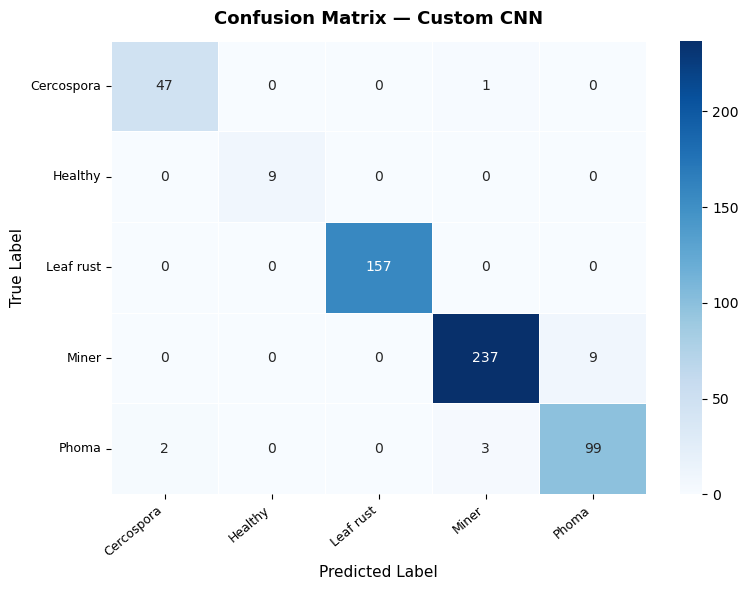

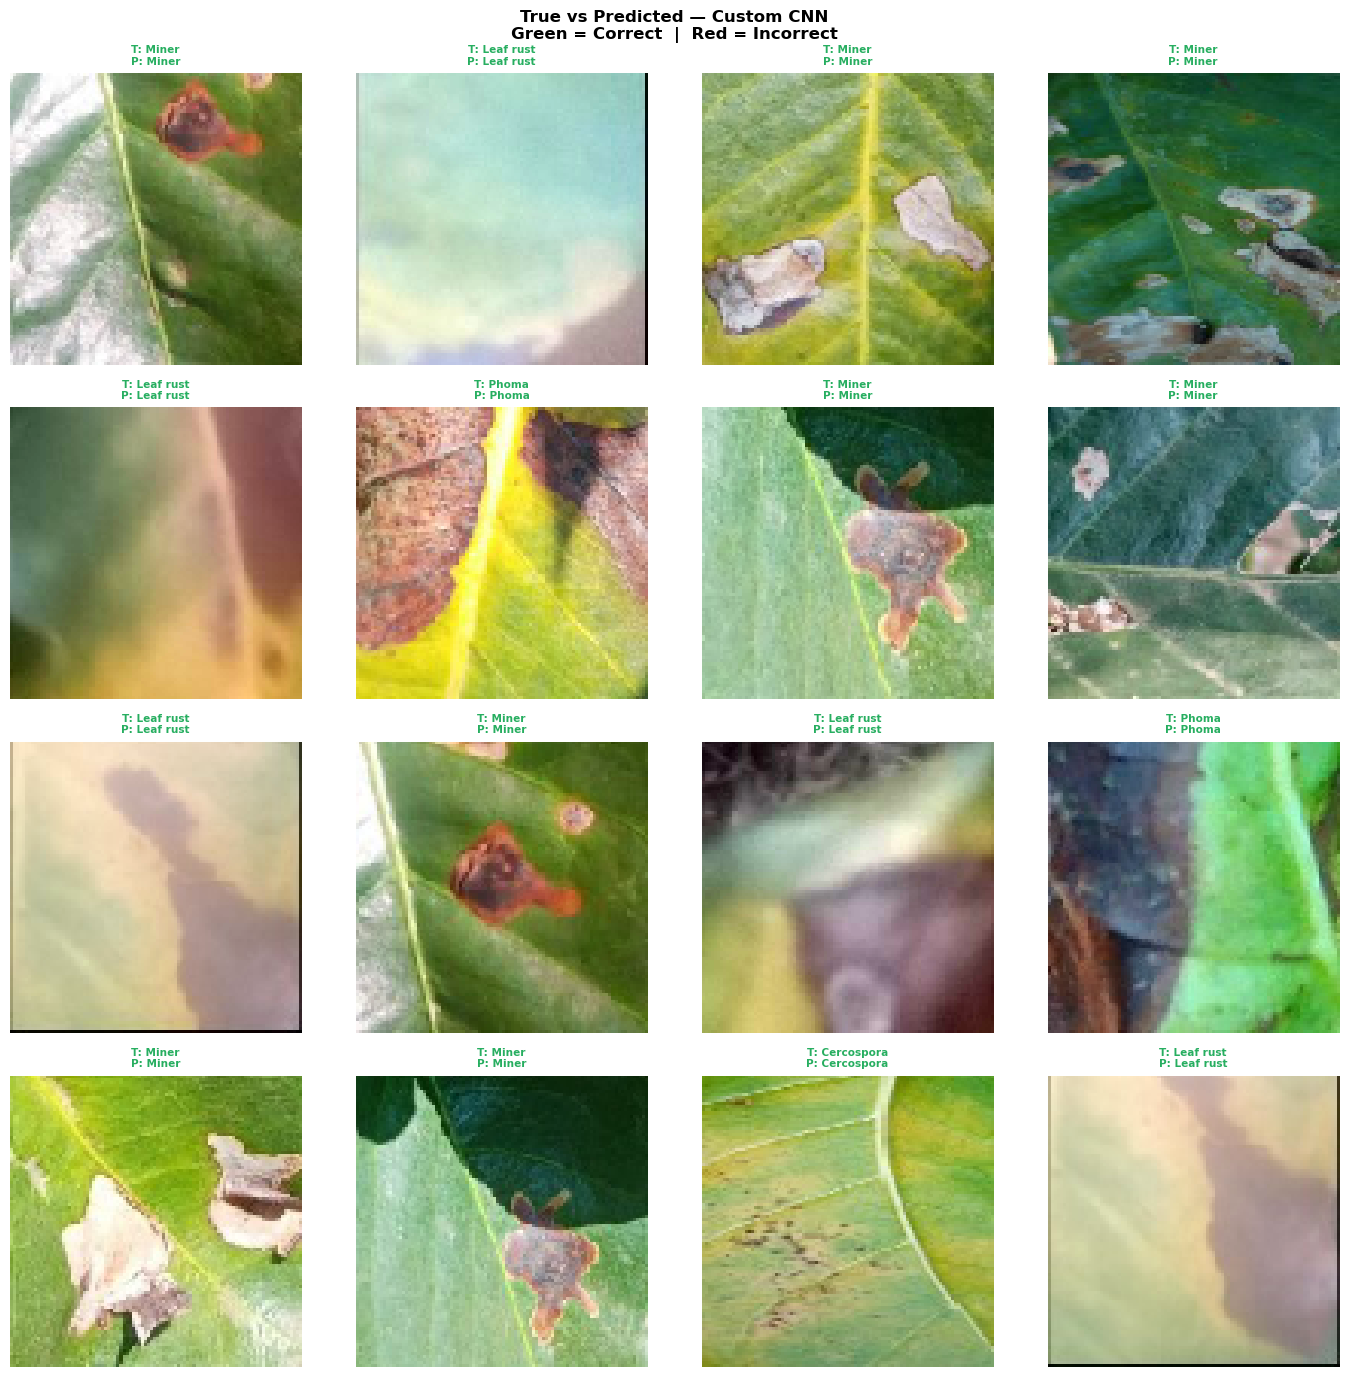

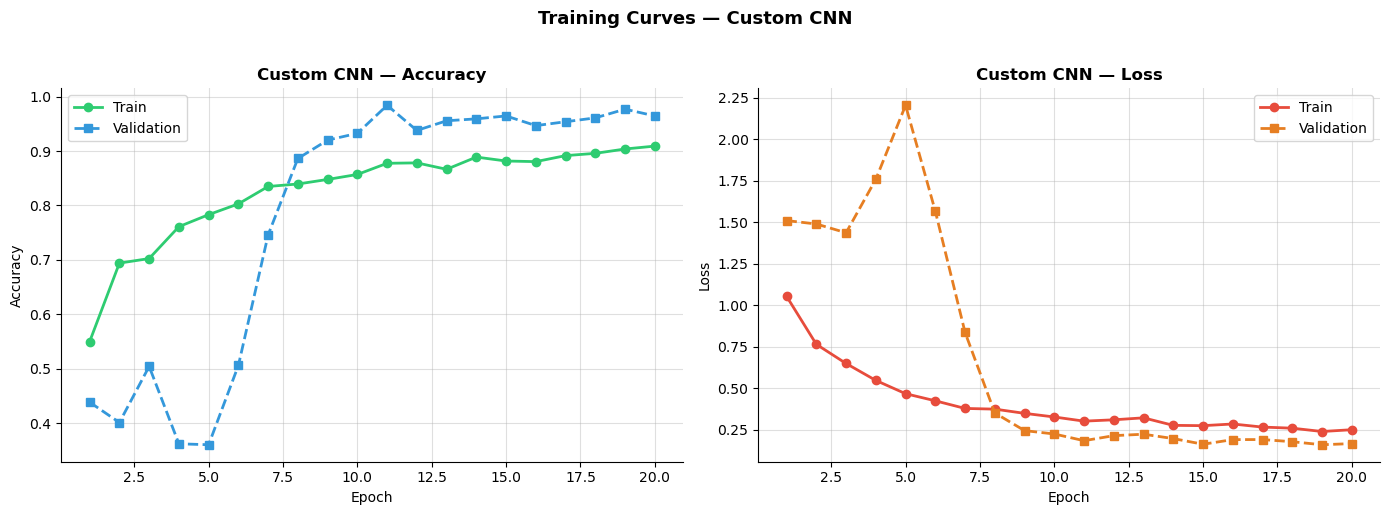

(0.9734042286872864, 0.14379490911960602)

In [32]:
evaluate_model(
    custom_cnn, test_gen_cnn, 'Custom CNN', history_cnn
)


  MobileNetV2 (Fine-Tuned)
  Test Accuracy : 0.9752  (97.52%)
  Test Loss     : 0.1236

── Classification Report ──
              precision    recall  f1-score   support

  Cercospora       0.86      1.00      0.92        48
     Healthy       1.00      1.00      1.00         9
   Leaf rust       1.00      0.99      1.00       157
       Miner       0.99      0.98      0.99       246
       Phoma       0.96      0.91      0.94       104

    accuracy                           0.98       564
   macro avg       0.96      0.98      0.97       564
weighted avg       0.98      0.98      0.98       564



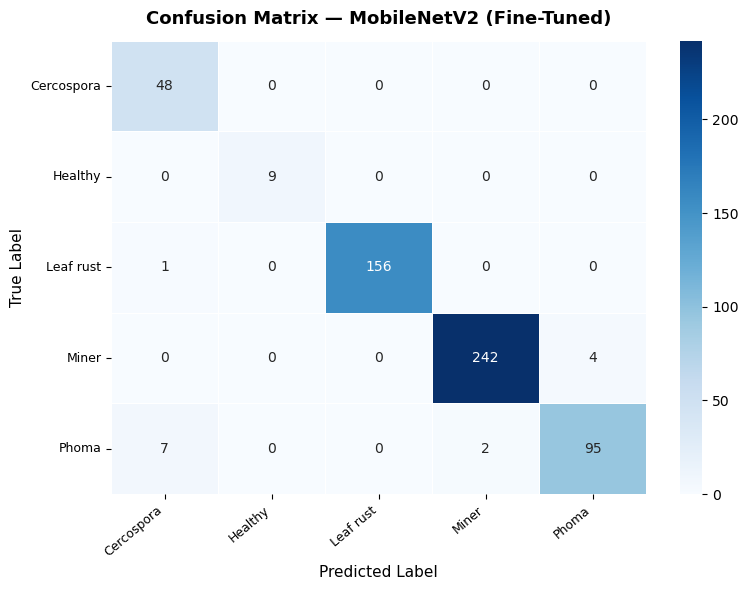

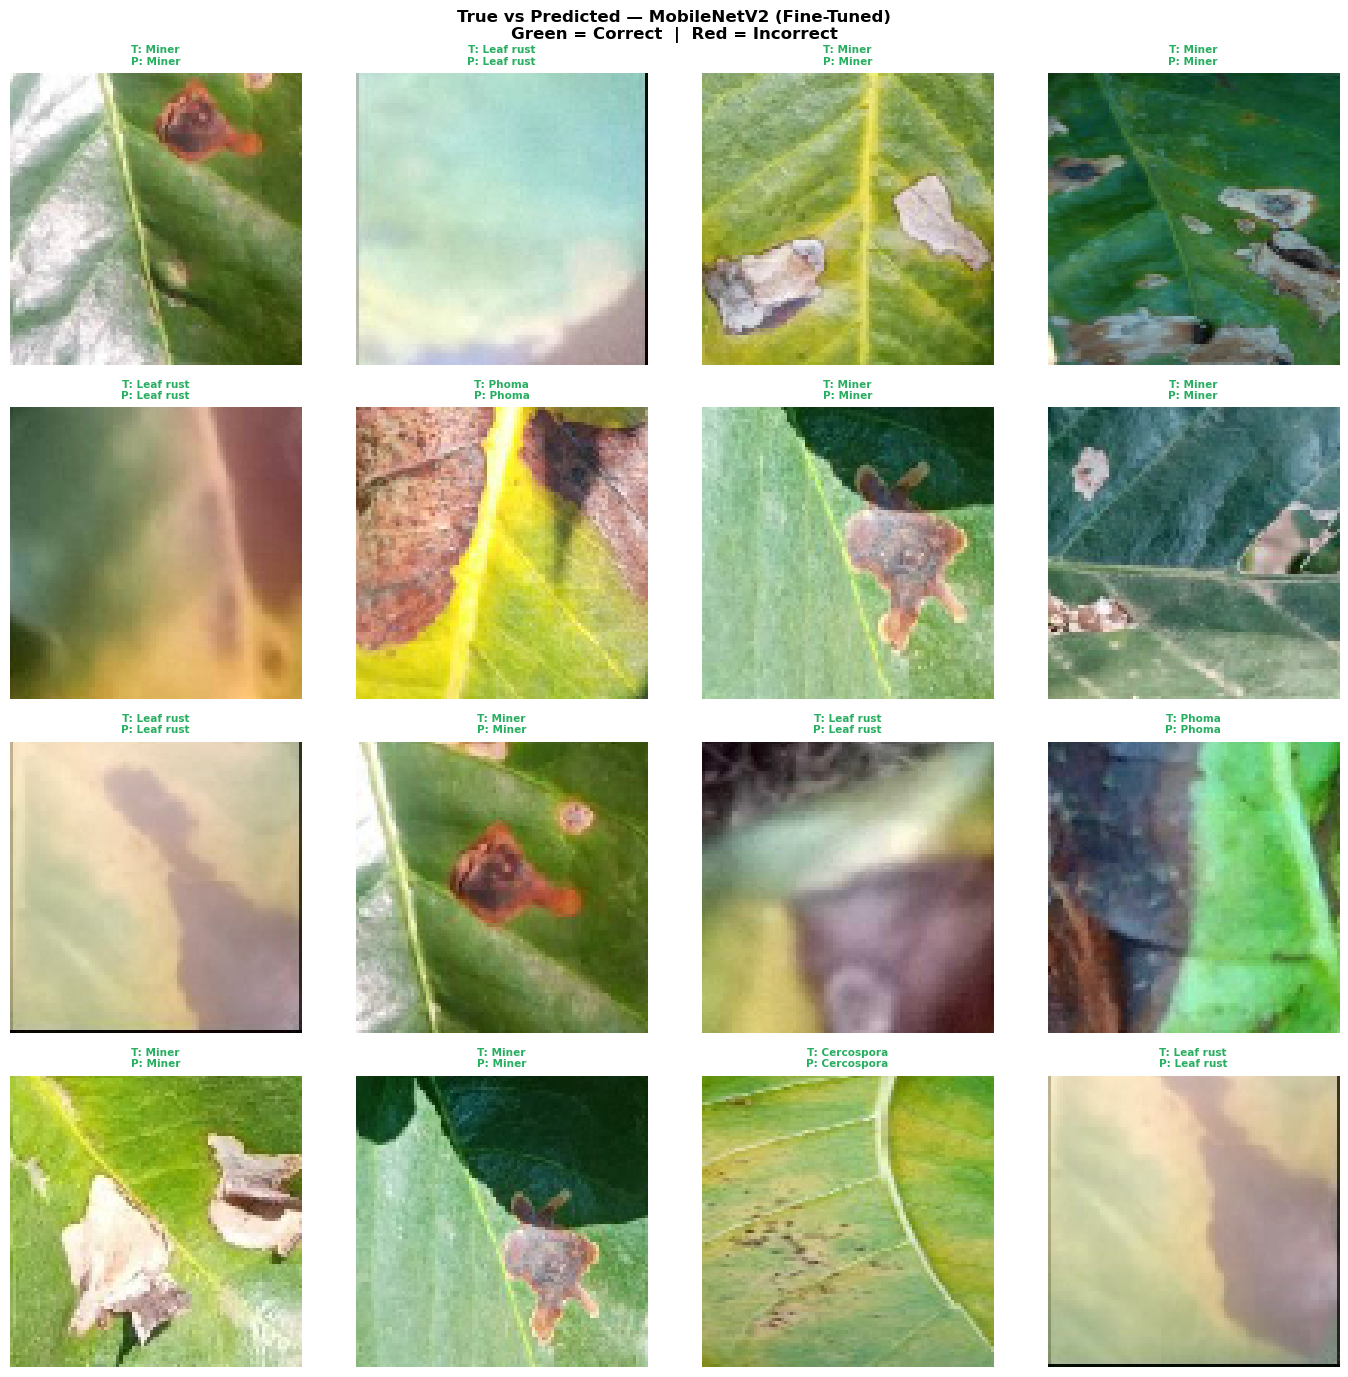

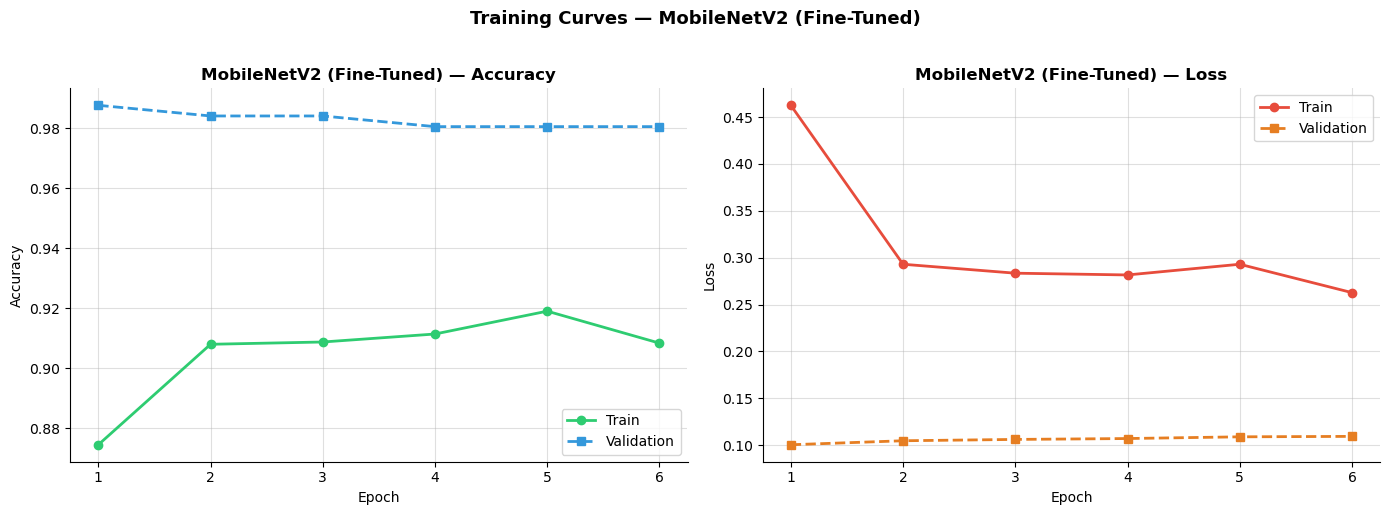

(0.9751772880554199, 0.12355386465787888)

In [33]:
evaluate_model(
    mobilenet_model, test_gen_mob, 'MobileNetV2 (Fine-Tuned)', history_mobilenet_ft
)


  EfficientNetB0 (Fine-Tuned)
  Test Accuracy : 0.9840  (98.40%)
  Test Loss     : 0.1207

── Classification Report ──
              precision    recall  f1-score   support

  Cercospora       0.96      0.98      0.97        48
     Healthy       1.00      1.00      1.00         9
   Leaf rust       1.00      0.99      1.00       157
       Miner       1.00      0.98      0.99       246
       Phoma       0.94      0.99      0.97       104

    accuracy                           0.98       564
   macro avg       0.98      0.99      0.98       564
weighted avg       0.98      0.98      0.98       564



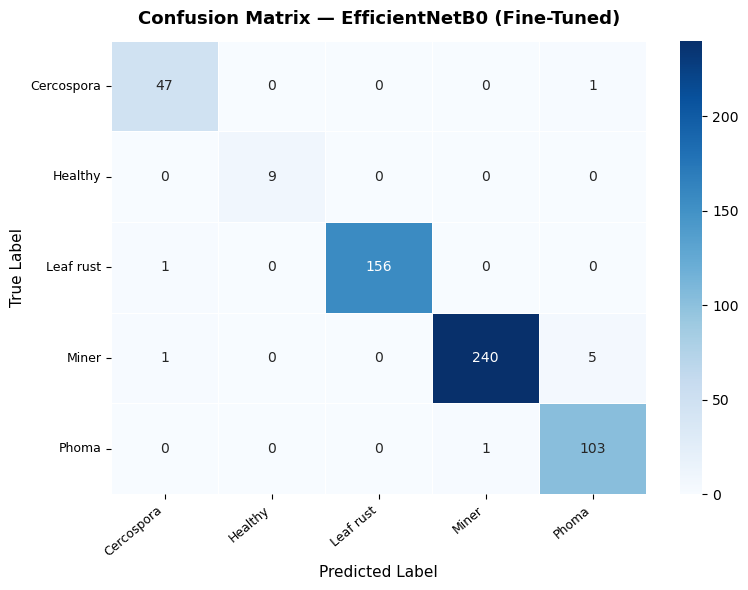

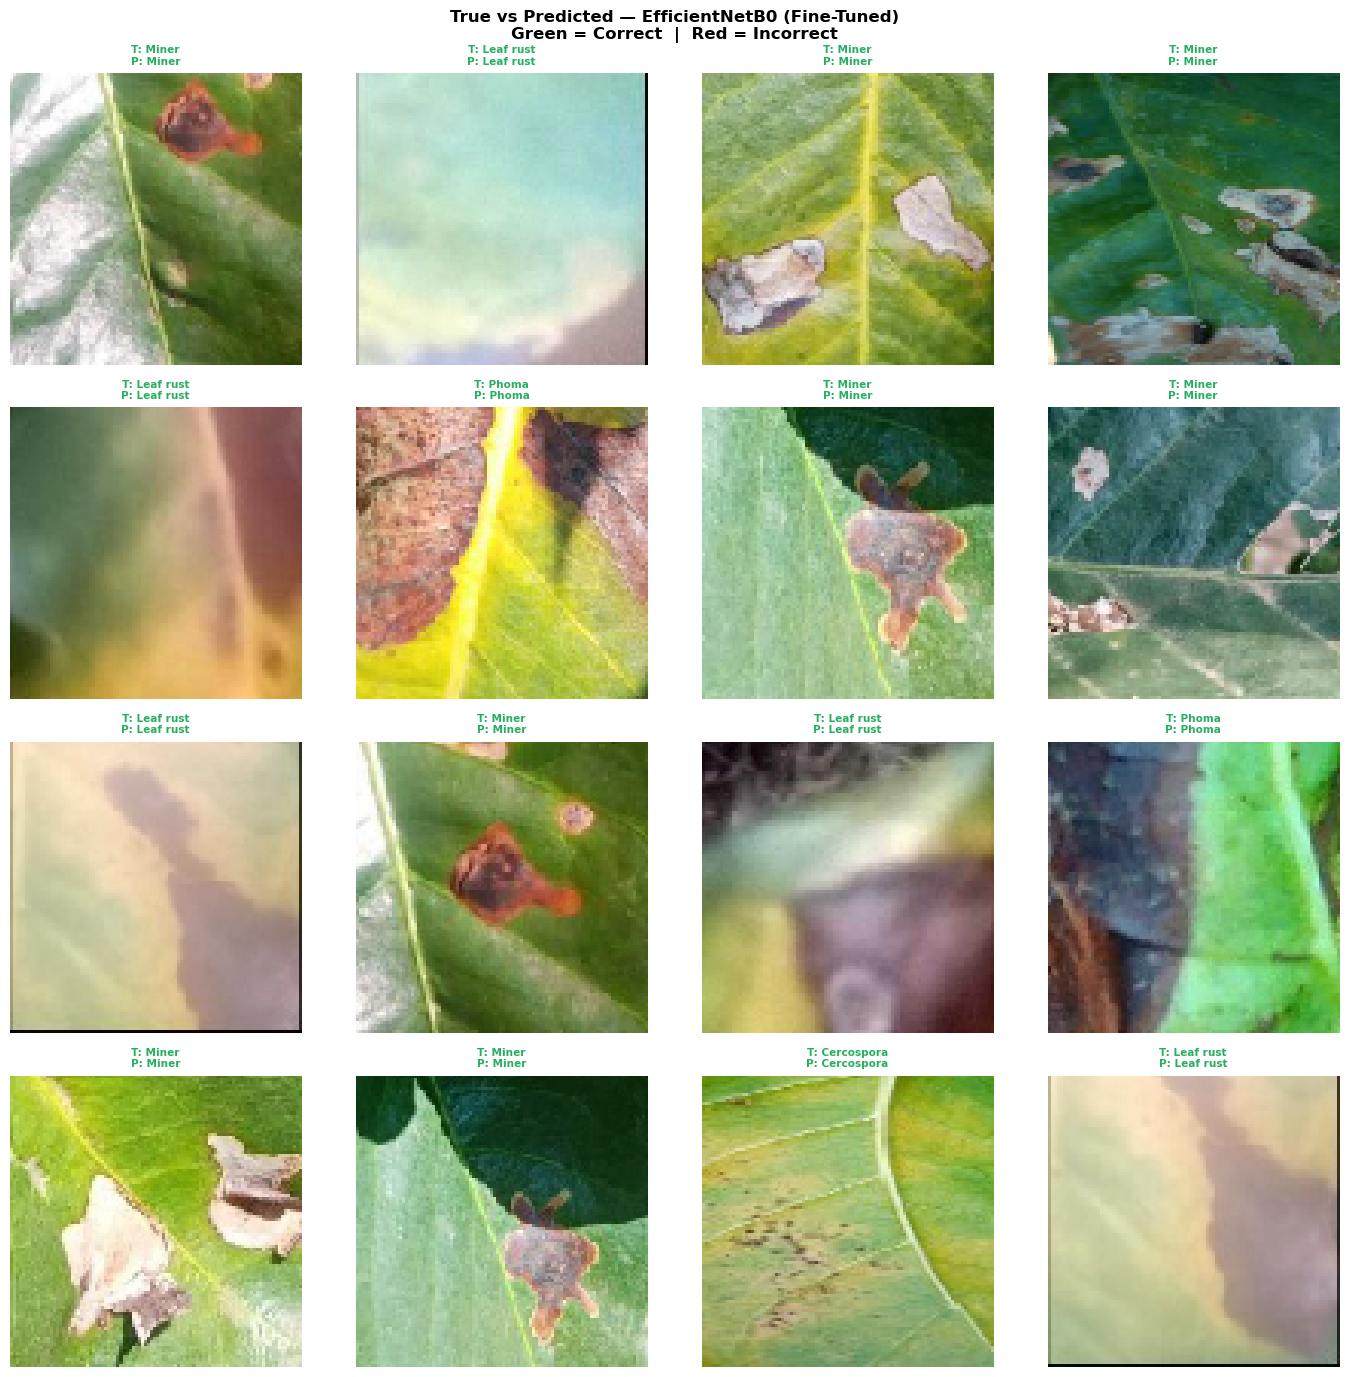

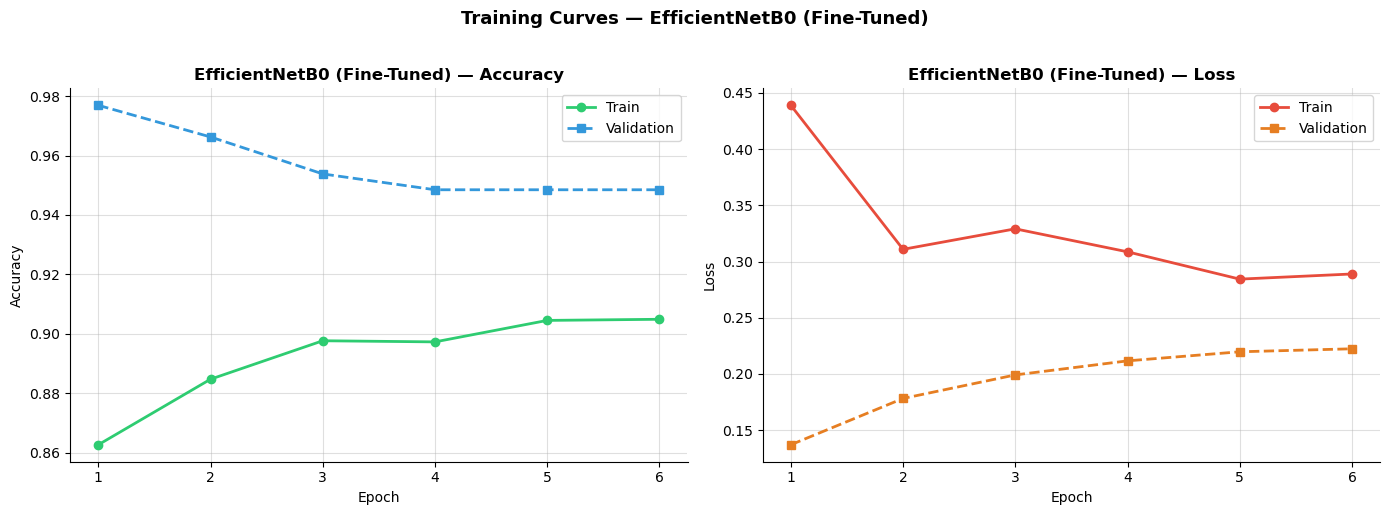

(0.9840425252914429, 0.120674267411232)

In [34]:
evaluate_model(
    efficientnet_model, test_gen_eff, 'EfficientNetB0 (Fine-Tuned)', history_efficientnet_ft
)

## Section 8 — Model Comparison & Final Results
Benchmarks inference latency for all three models and compiles a unified comparison table covering test accuracy, parameter count, memory footprint, and inference speed — the three axes of the deployment trade-off.

In [35]:
# ── 8.1 Inference Latency Benchmarking (single image, 20 runs) ───────────────
bench_configs = [
    ('Custom CNN', custom_cnn, test_gen_cnn),
    ('MobileNetV2 (Fine-Tuned)', mobilenet_model, test_gen_mob),
    ('EfficientNetB0 (Fine-Tuned)', efficientnet_model, test_gen_eff),
]

inference_times = {}
for name, model, gen in bench_configs:
    gen.reset()
    single_img = next(gen)[0][:1]
    for _ in range(5):
        model.predict(single_img, verbose=0)
    times = []
    for _ in range(20):
        t0 = time.perf_counter()
        model.predict(single_img, verbose=0)
        times.append((time.perf_counter() - t0) * 1000)
    mean_ms = np.mean(times)
    inference_times[name] = mean_ms
    print(f"{name:<38}: {mean_ms:>6.1f} ms  (±{np.std(times):.1f} ms)")


Custom CNN                            :   94.8 ms  (±13.7 ms)
MobileNetV2 (Fine-Tuned)              :   92.1 ms  (±15.1 ms)
EfficientNetB0 (Fine-Tuned)           :  105.8 ms  (±18.3 ms)


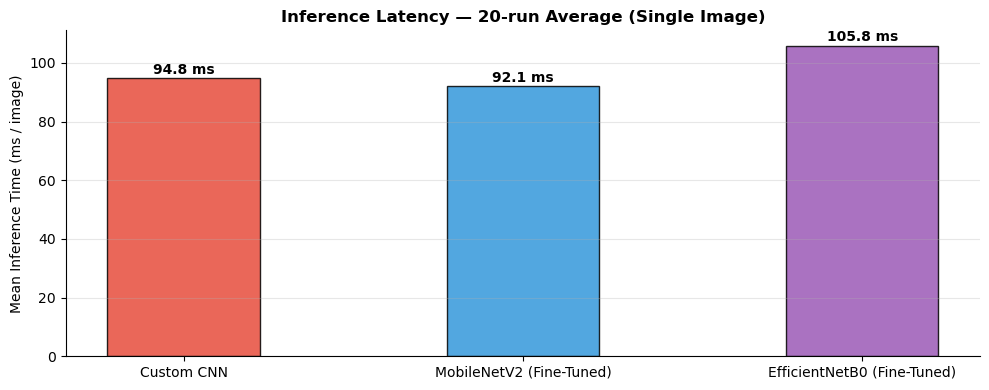

In [36]:
# ── 8.2 Inference Time Bar Chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
names_inf = list(inference_times.keys())
vals_inf  = list(inference_times.values())
colors_inf = ['#e74c3c', '#3498db', '#9b59b6']

bars_inf = ax.bar(names_inf, vals_inf, color=colors_inf, edgecolor='black', alpha=0.85, width=0.45)
for bar, v in zip(bars_inf, vals_inf):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{v:.1f} ms', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylabel('Mean Inference Time (ms / image)')
ax.set_title('Inference Latency — 20-run Average (Single Image)', fontweight='bold', fontsize=12)
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('inference_latency.png', dpi=150)
plt.show()

In [37]:
# ── 8.3 Final Comparison Table ────────────────────────────────────────────────
results = []
for name, model, gen in bench_configs:
    gen.reset()
    t_loss, t_acc = model.evaluate(gen, verbose=0)
    total     = model.count_params()
    trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
    results.append({
        'Model'              : name,
        'Test Accuracy (%)'  : f'{t_acc * 100:.2f}',
        'Test Loss'          : f'{t_loss:.4f}',
        'Total Params'       : f'{total:,}',
        'Trainable Params'   : f'{trainable:,}',
        'Inference (ms/img)' : f'{inference_times[name]:.1f}',
        'Memory (MB)'        : f'{total * 4 / 1e6:.1f}',
    })

summary_df = pd.DataFrame(results)
print('=' * 100)
print('FINAL MODEL COMPARISON — Coffee Disease Classification')
print('Custom CNN vs MobileNetV2 (Fine-Tuned) vs EfficientNetB0 (Fine-Tuned)')
print('=' * 100)
print(summary_df.to_string(index=False))


FINAL MODEL COMPARISON — Coffee Disease Classification
Custom CNN vs MobileNetV2 (Fine-Tuned) vs EfficientNetB0 (Fine-Tuned)
                      Model Test Accuracy (%) Test Loss Total Params Trainable Params Inference (ms/img) Memory (MB)
                 Custom CNN             97.34    0.1438      217,989          215,237               94.8         0.9
   MobileNetV2 (Fine-Tuned)             97.52    0.1236    2,619,461        1,567,557               92.1        10.5
EfficientNetB0 (Fine-Tuned)             98.40    0.1207    4,411,048        1,712,437              105.8        17.6


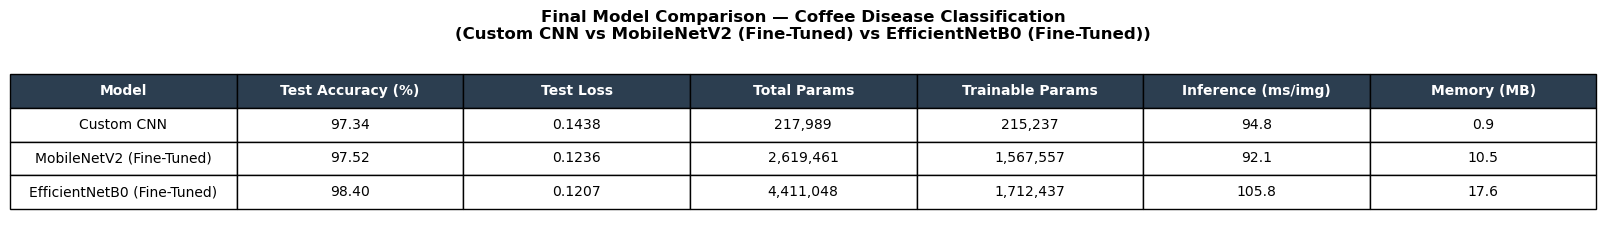

In [38]:
# ── 8.4 Comparison Table Visualisation ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 2.5))
ax.axis('off')
tbl = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 2.2)
for j in range(len(summary_df.columns)):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

plt.title('Final Model Comparison — Coffee Disease Classification\n(Custom CNN vs MobileNetV2 (Fine-Tuned) vs EfficientNetB0 (Fine-Tuned))',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('final_comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()


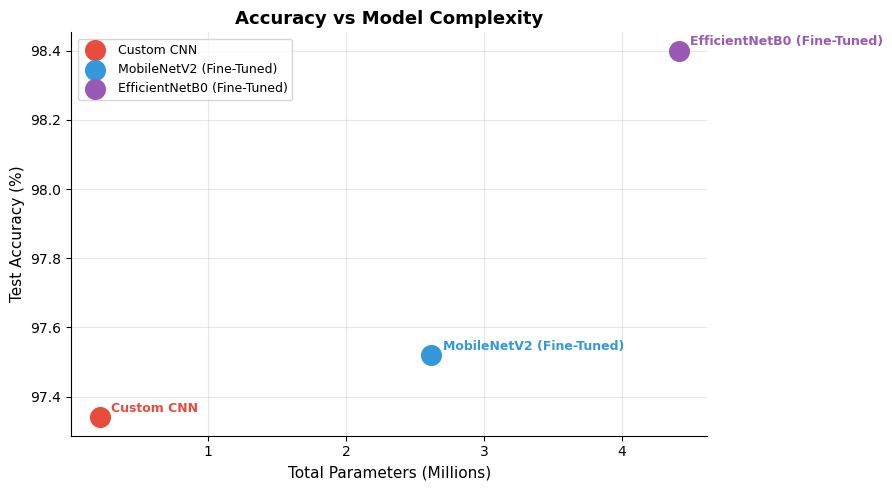

In [39]:
# ── 8.5 Accuracy vs Parameter Count Scatter ──────────────────────────────────
param_counts = [m.count_params() / 1e6 for _, m, _ in bench_configs]
accuracies   = [float(r['Test Accuracy (%)']) for r in results]
model_labels = [r['Model'] for r in results]
colors_sc    = ['#e74c3c', '#3498db', '#9b59b6']

fig, ax = plt.subplots(figsize=(9, 5))
for i, (x_val, y_val, lbl, c) in enumerate(zip(param_counts, accuracies, model_labels, colors_sc)):
    ax.scatter(x_val, y_val, s=200, color=c, zorder=5, label=lbl)
    ax.annotate(lbl, (x_val, y_val), textcoords='offset points',
                xytext=(8, 4), fontsize=9, color=c, fontweight='bold')

ax.set_xlabel('Total Parameters (Millions)', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Accuracy vs Model Complexity', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('accuracy_vs_params.png', dpi=150)
plt.show()

## Section 9 — Save Models
Serialises all trained models to disk in Keras's `.keras` format for future inference, fine-tuning, or deployment conversion (e.g., TFLite for mobile field devices).

In [40]:
# ── Save all models ───────────────────────────────────────────────────────────
custom_cnn.save('custom_cnn.keras')
mobilenet_model.save('mobilenetv2_finetuned.keras')
efficientnet_model.save('efficientnetb0_finetuned.keras')

print("Models saved:")
for fname in ['custom_cnn.keras', 'mobilenetv2_finetuned.keras', 'efficientnetb0_finetuned.keras']:
    size_mb = os.path.getsize(fname) / 1e6 if os.path.exists(fname) else 0
    print(f"  {fname:<42}  ({size_mb:.1f} MB)")


Models saved:
  custom_cnn.keras                            (2.8 MB)
  mobilenetv2_finetuned.keras                 (23.6 MB)
  efficientnetb0_finetuned.keras              (32.2 MB)
